# Proyecto de Aula: Modelado y análisis de la red del Metro de Madrid

**Asignaturas**: Algoritmos y Programación - Matemáticas Discretas
**Semestre**: 2026-2



##  Importación de Módulos y Construcción del Grafo

El grafo tiene 291 nodos y 338 aristas.


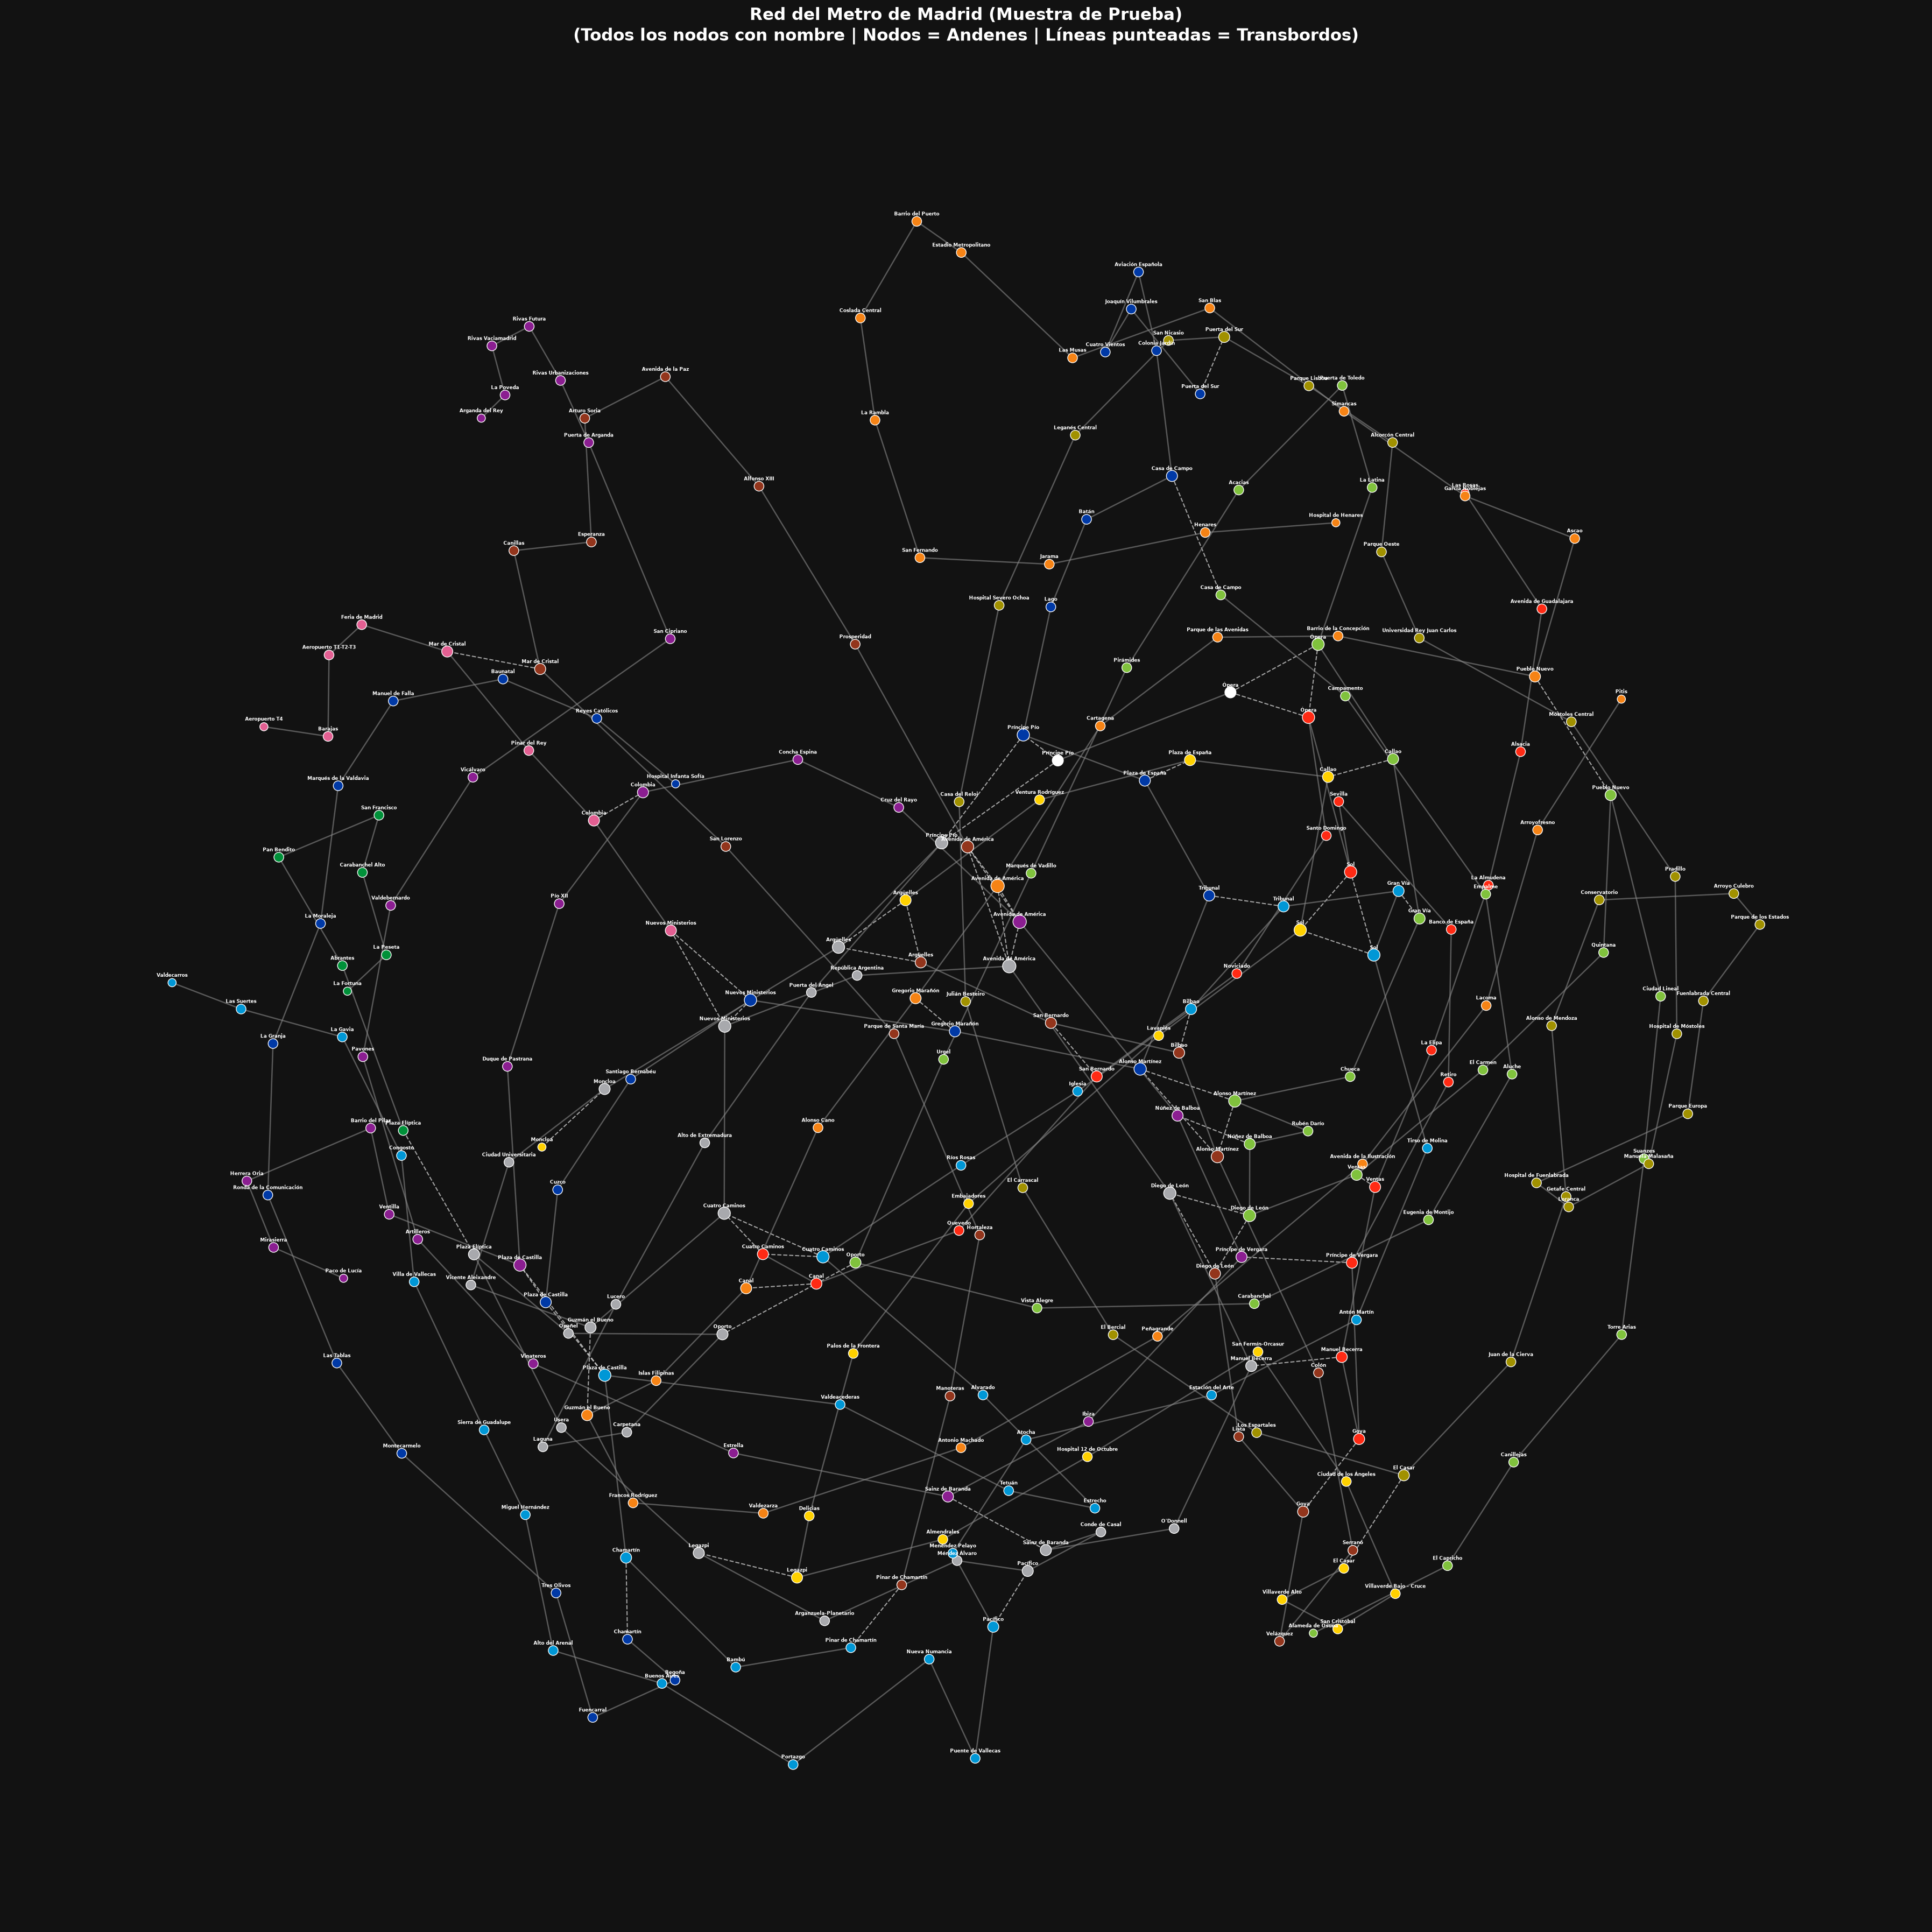

In [18]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

from graph_builder import load_data, build_metro_graph
from algorithms import compare_routes
from metrics import get_all_metrics, get_top_stations_by_degree, get_top_stations_by_betweenness
from robustness import identify_articulation_points, simulate_node_removal
from visualization import plot_graph_matplotlib,plot_graph_pyvis,plot_route_matplotlib,plot_failed_station_matplotlib

## Cargar datos y construir grafo
data = load_data('../data/metro_madrid.json')
G = build_metro_graph(data)
print(f"El grafo tiene {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas.")
plot_graph_matplotlib(G, title="Red del Metro de Madrid (Muestra de Prueba)")

##  Cálculo de la Ruta Óptima 


--- Rutas desde Cartagena hasta sol ---
Dijkstra (menor tiempo):
  Ruta: ['Cartagena [L7]', 'Avenida de América [L7]', 'Gregorio Marañón [L7]', 'Gregorio Marañón [L10]', 'Alonso Martínez [L10]', 'Tribunal [L10]', 'Tribunal [L1]', 'Gran Vía [L1]', 'Sol [L1]']
  Tiempo total: 16:00 minutos

BFS (menor número de paradas):
  Ruta: ['Cartagena [L7]', 'Avenida de América [L7]', 'Gregorio Marañón [L7]', 'Alonso Cano [L7]', 'Canal [L7]', 'Canal [L2]', 'Quevedo [L2]', 'San Bernardo [L2]', 'Noviciado [L2]', 'Santo Domingo [L2]', 'Ópera [L2]', 'Sol [L2]']
  Total de paradas: 10


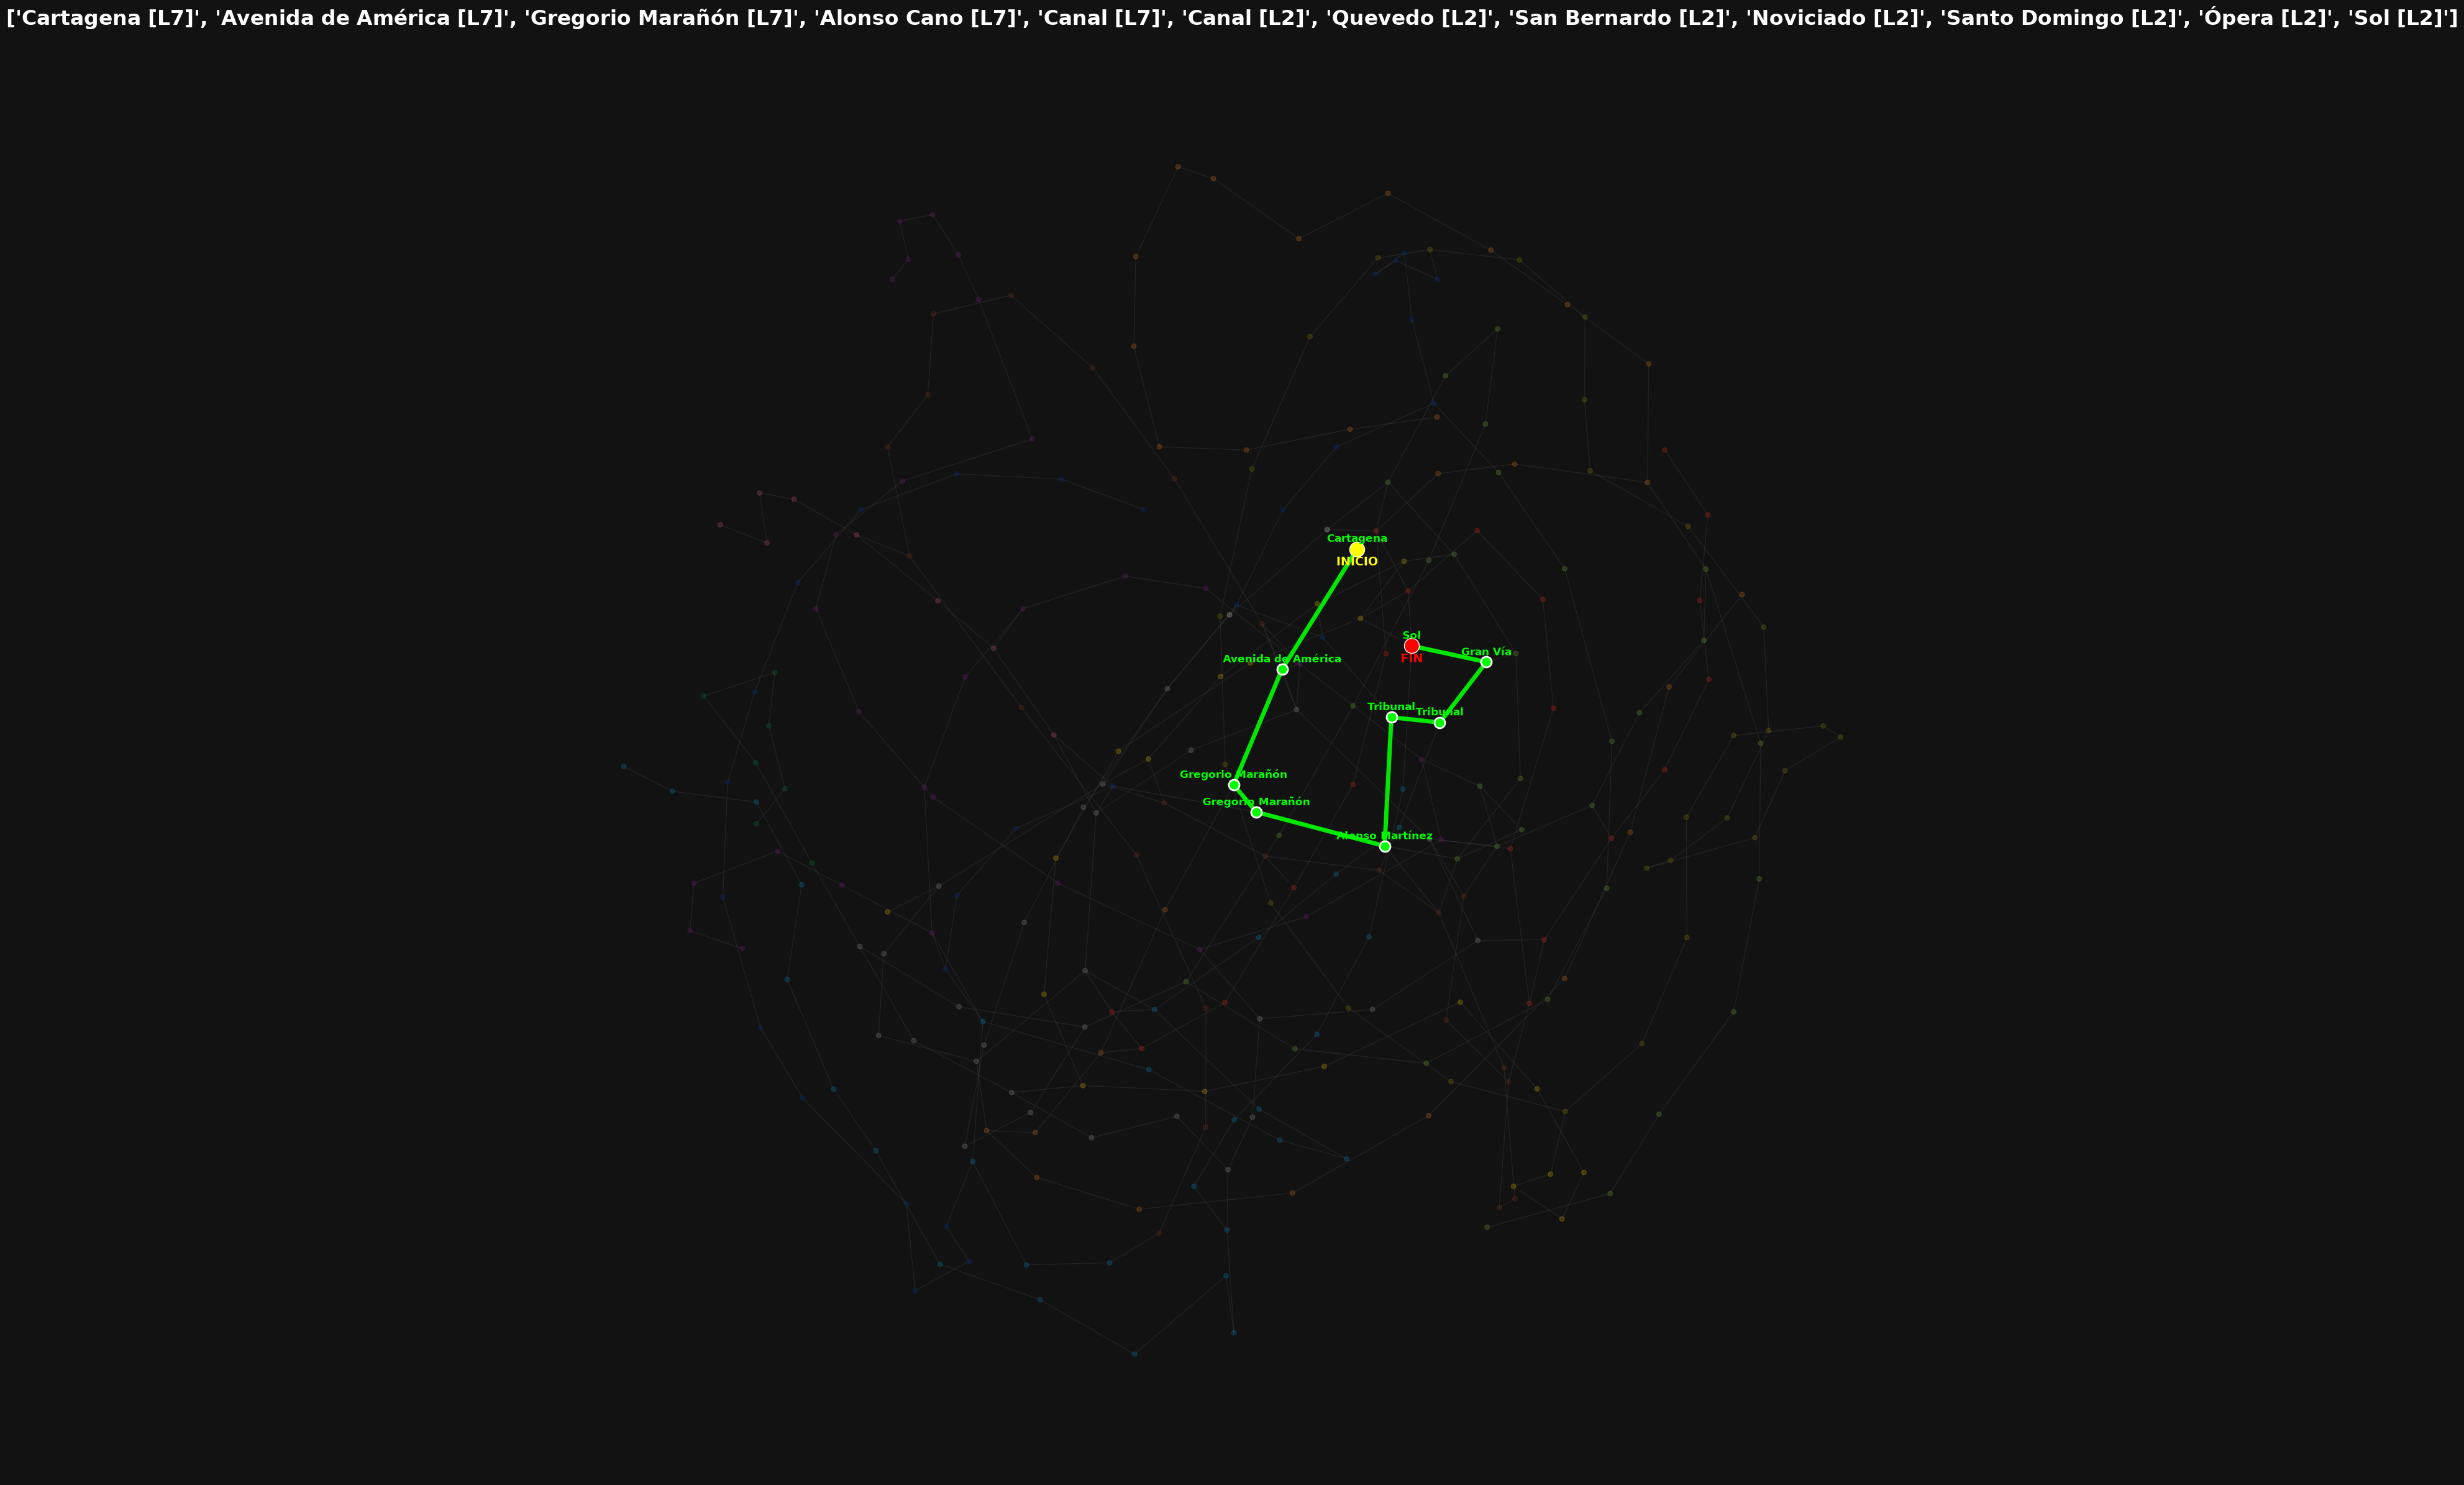

In [19]:
origen = 'Cartagena'
destino = 'sol'

rutas = compare_routes(G, origen, destino)

print(f"--- Rutas desde {origen} hasta {destino} ---")
print("Dijkstra (menor tiempo):")
print(f"  Ruta: {rutas['dijkstra']['path']}")
print(f"  Tiempo total: {rutas['dijkstra']['time']} minutos")
print("\nBFS (menor número de paradas):")
print(f"  Ruta: {rutas['bfs']['path']}")
print(f"  Total de paradas: {rutas['bfs']['stops']}")
plot_route_matplotlib(G,rutas['dijkstra']['path'],rutas['bfs']['path'])

##  Métricas de Teoría de Grafos

In [20]:
metricas = get_all_metrics(G)

print("--- Métricas de la Red ---")
print(f"Densidad: {metricas['density']:.4f}")
print(f"Diámetro: {metricas['diameter']}")

# Ordenar nodos por grado
grados_ordenados = sorted(metricas['degree'].items(), key=lambda x: x[1], reverse=True)
print("\nEstaciones con mayor grado (top 5):")
for nodo, grado in grados_ordenados[:5]:
    print(f"  - {nodo}: {grado}")
    
# Ordenar nodos por centralidad de intermediación
centralidad_ordenada = sorted(metricas['betweenness_centrality'].items(), key=lambda x: x[1], reverse=True)
print("\nEstaciones más centrales (top 5):")
for nodo, centr in centralidad_ordenada[:5]:
    print(f"  - {nodo}: {centr:.4f}")

--- Métricas de la Red ---
Densidad: 0.0080
Diámetro: 46

Estaciones con mayor grado (top 5):
  - Avenida de América [L9]: 5
  - Avenida de América [L7]: 5
  - Avenida de América [L6]: 5
  - Príncipe Pío [L10]: 4
  - Príncipe Pío [L6]: 4

Estaciones más centrales (top 5):
  - Legazpi [L3]: 0.1544
  - Pacífico [L6]: 0.1475
  - Sainz de Baranda [L6]: 0.1373
  - Plaza de Castilla [L1]: 0.1354
  - Príncipe Pío [L10]: 0.1339


##  Análisis de Conectividad y Robustez

--- Puntos de Articulación ---
Nodos críticos que desconectarían la red si fallan: ['La Peseta [L11]', 'Carabanchel Alto [L11]', 'San Francisco [L11]', 'Pan Bendito [L11]', 'Abrantes [L11]', 'Arroyofresno [L7]', 'Lacoma [L7]', 'Avenida de la Ilustración [L7]', 'Peñagrande [L7]', 'Antonio Machado [L7]', 'Valdezarza [L7]', 'Francos Rodríguez [L7]', 'Guzmán el Bueno [L7]', 'Las Suertes [L1]', 'La Gavia [L1]', 'Congosto [L1]', 'Villa de Vallecas [L1]', 'Sierra de Guadalupe [L1]', 'Miguel Hernández [L1]', 'Alto del Arenal [L1]', 'Buenos Aires [L1]', 'Portazgo [L1]', 'Nueva Numancia [L1]', 'Puente de Vallecas [L1]', 'Pacífico [L1]', 'Mirasierra [L9]', 'Herrera Oria [L9]', 'Barrio del Pilar [L9]', 'Ventilla [L9]', 'Plaza de Castilla [L9]', 'Barajas [L8]', 'Aeropuerto T1-T2-T3 [L8]', 'Feria de Madrid [L8]', 'Mar de Cristal [L8]', 'La Poveda [L9]', 'Rivas Vaciamadrid [L9]', 'Rivas Futura [L9]', 'Rivas Urbanizaciones [L9]', 'Puerta de Arganda [L9]', 'San Cipriano [L9]', 'Vicálvaro [L9]', 'Valdeb

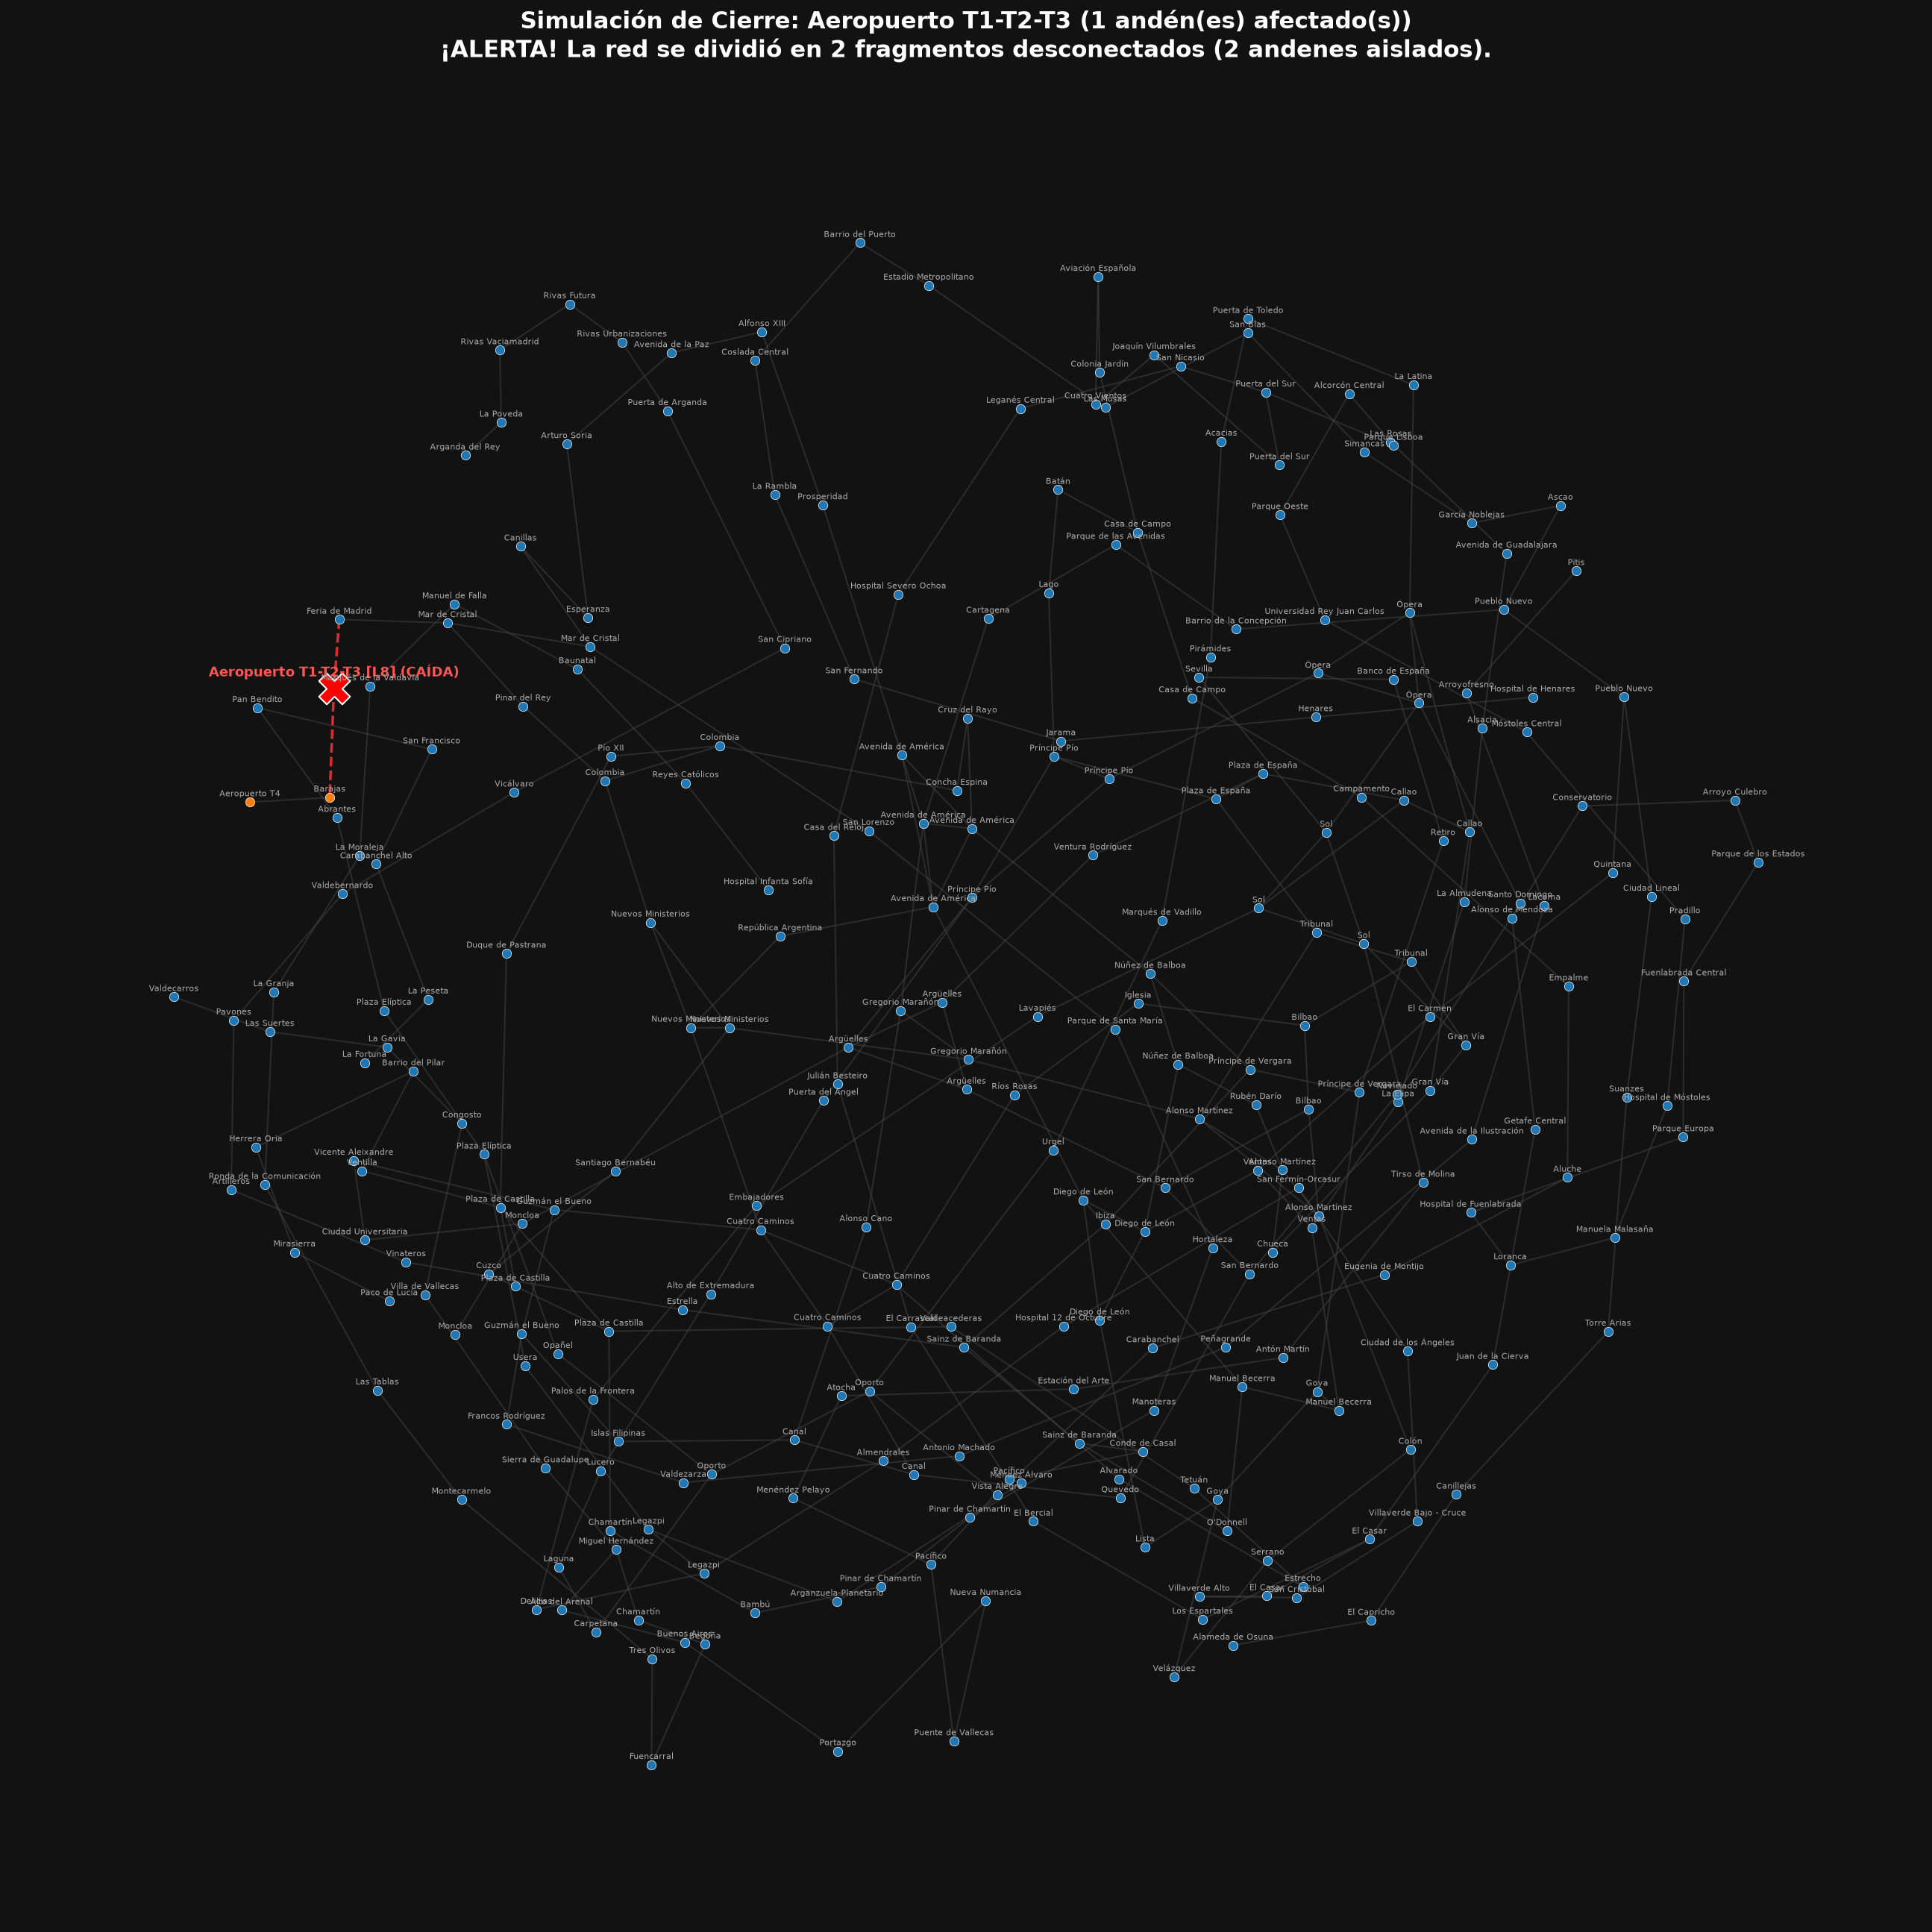

In [21]:
puntos_articulacion = identify_articulation_points(G)
print("--- Puntos de Articulación ---")
print(f"Nodos críticos que desconectarían la red si fallan: {puntos_articulacion}")
print(f"Número de puntos de articulación: {len(puntos_articulacion)}")

print("\n--- Simulación de Fallo ---")
nodo_fallo = 'Aeropuerto T1-T2-T3'
resultado = simulate_node_removal(G, nodo_fallo)
print(f"Simulando la eliminación de la estación '{nodo_fallo}'...")
print(f"¿Sigue conectada la red? {'Sí' if resultado['is_connected'] else 'No'}")
print(f"Número de componentes conectados: {resultado['num_components']}")
plot_failed_station_matplotlib(G, nodo_fallo)

In [22]:
plot_graph_pyvis(G)

Visualización interactiva guardada en: metro_madrid_pyvis.html
